In [1]:
#This code block contains the trainng and testing of random forest model

In [22]:
pip install pandas scikit-learn matplotlib seaborn

Note: you may need to restart the kernel to use updated packages.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score, root_mean_squared_error
from sklearn.model_selection import train_test_split

In [2]:
file = "../Dataset/final_sdb_dataset_clean.csv"
df = pd.read_csv(file)
df_shallow = df[(df['depth'] >= 0) & (df['depth'] <= 30)].copy()


In [3]:
print(f"Original rows: {len(df)} | Rows after filtering (depth <= 30): {len(df_shallow)}")

Original rows: 11676 | Rows after filtering (depth <= 30): 4548


In [6]:
df_arabian_sea = df_shallow[(df_shallow['longitude'] > 48) & (df_shallow['longitude'] < 60)].copy()
df_strait_of_hormuz = df_shallow[(df_shallow['longitude'] > 65) & (df_shallow['longitude'] < 70)].copy()
df_bay_of_bengal = df_shallow[df_shallow['longitude'] >= 70].copy()

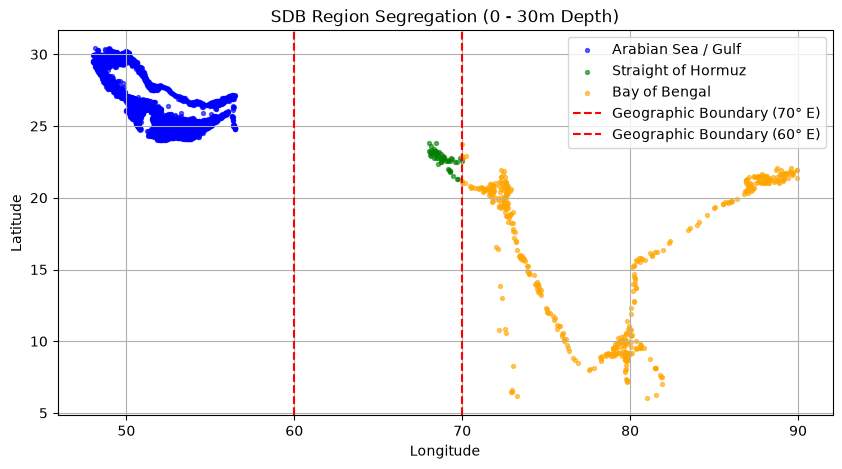

In [7]:
plt.figure(figsize=(10, 5))
plt.scatter(df_arabian_sea['longitude'], df_arabian_sea['latitude'], c='blue', label='Arabian Sea / Gulf', s=8, alpha=0.6)
plt.scatter(df_strait_of_hormuz['longitude'], df_strait_of_hormuz['latitude'], c='green', label='Straight of Hormuz', s=8, alpha=0.6)
plt.scatter(df_bay_of_bengal['longitude'], df_bay_of_bengal['latitude'], c='orange', label='Bay of Bengal', s=8, alpha=0.6)
plt.axvline(x=70, color='red', linestyle='--', label='Geographic Boundary (70° E)')
plt.axvline(x=60, color='red', linestyle='--', label='Geographic Boundary (60° E)')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('SDB Region Segregation (0 - 30m Depth)')
plt.legend()
plt.grid(True)
plt.show()

In [4]:
features = ['blue_band', 
            'green_band', 
            'log_blue', 
            'log_green', 
            'bg_ratio', 
            'stumpf_ratio']
X = df_shallow[features]
y = df_shallow['depth']

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [9]:
rf_model = RandomForestRegressor(
    n_estimators=100, 
    max_depth=15, 
    random_state=42, 
    n_jobs=-1
)
rf_model.fit(X_train, y_train)

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",15
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max

In [10]:
y_pred = rf_model.predict(X_test)

In [11]:
mae = mean_absolute_error(y_test, y_pred)
rmse = root_mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"--- Model Performance Metrics ---")
print(f"MAE  : {mae:.4f} meters")
print(f"RMSE : {rmse:.4f} meters")
print(f"R²   : {r2:.4f}")

--- Model Performance Metrics ---
MAE  : 5.0608 meters
RMSE : 6.6561 meters
R²   : 0.4375


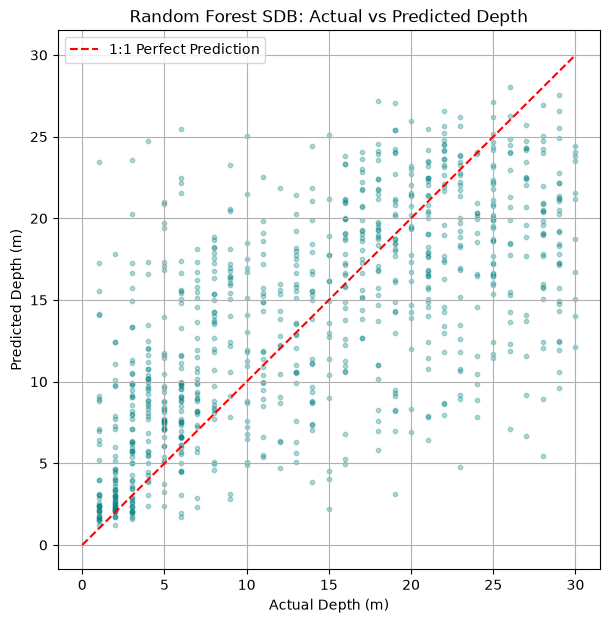

In [12]:
plt.figure(figsize=(7, 7))
plt.scatter(y_test, y_pred, alpha=0.3, color='teal', s=10)
plt.plot([0, 30], [0, 30], 'r--', label='1:1 Perfect Prediction')
plt.xlabel('Actual Depth (m)')
plt.ylabel('Predicted Depth (m)')
plt.title('Random Forest SDB: Actual vs Predicted Depth')
plt.legend()
plt.grid(True)
plt.show()

=== Arabian Sea / Gulf (N=4067) ===
  MAE  : 4.7710 m
  RMSE : 6.4024 m
  R²   : 0.4605

=== Strait of Hormuz (N=54) ===
  MAE  : 1.9618 m
  RMSE : 2.6047 m
  R²   : 0.8251

=== Bay of Bengal (N=427) ===
  MAE  : 5.9502 m
  RMSE : 7.4412 m
  R²   : 0.2476



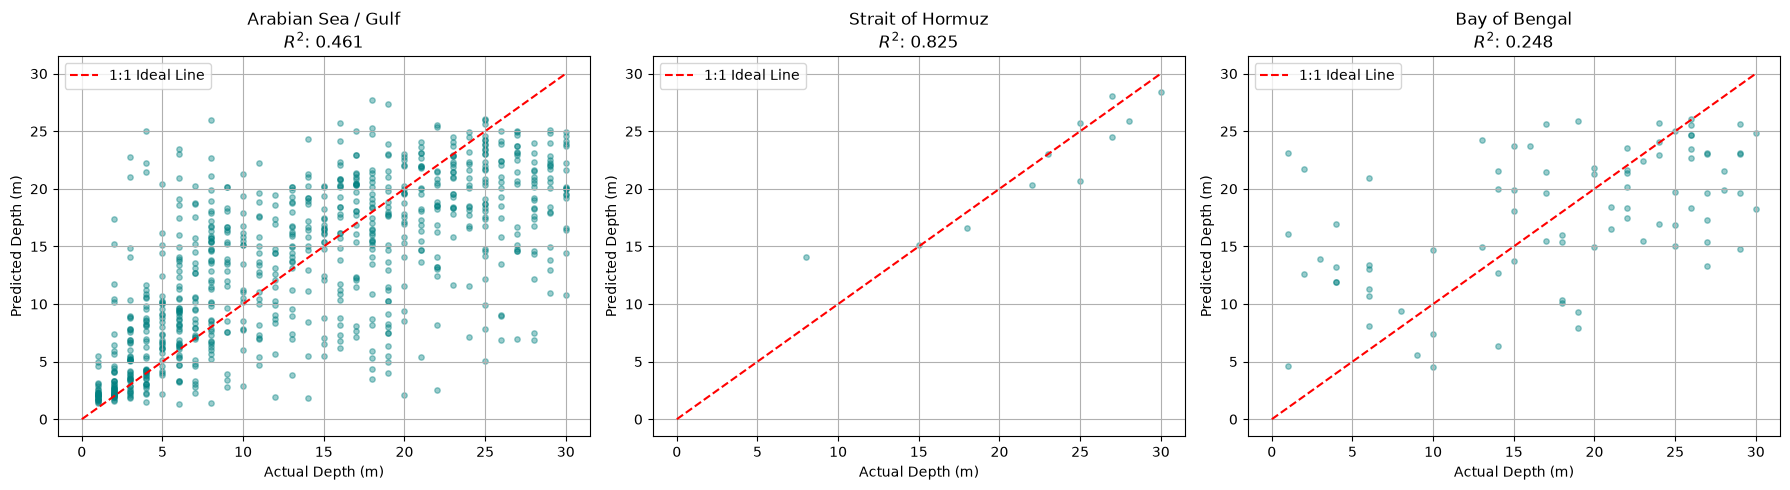

In [14]:
regions = [
    ('Arabian Sea / Gulf', df_arabian_sea),
    ('Strait of Hormuz', df_strait_of_hormuz),
    ('Bay of Bengal', df_bay_of_bengal)
]

features = ['blue_band', 
            'green_band', 
            'log_blue', 
            'log_green', 
            'bg_ratio', 
            'stumpf_ratio']

# Dictionary to store trained models for later use if needed
trained_models = {}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, (name, region_df) in enumerate(regions):
    if len(region_df) == 0:
        print(f"Skipping {name}: No samples available.")
        continue
        
    X_reg = region_df[features]
    y_reg = region_df['depth']
    
    # Train-test split for the specific region
    X_train, X_test, y_train, y_test = train_test_split(
        X_reg, y_reg, test_size=0.2, random_state=42
    )
    
    # Fit individual Random Forest model
    rf = RandomForestRegressor(n_estimators=100, max_depth=15, random_state=42, n_jobs=-1)
    rf.fit(X_train, y_train)
    trained_models[name] = rf
    
    # Predict and Evaluate
    y_pred = rf.predict(X_test)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = root_mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    
    print(f"=== {name} (N={len(region_df)}) ===")
    print(f"  MAE  : {mae:.4f} m")
    print(f"  RMSE : {rmse:.4f} m")
    print(f"  R²   : {r2:.4f}\n")
    
    # Plot Actual vs Predicted per region
    ax = axes[idx]
    ax.scatter(y_test, y_pred, alpha=0.4, s=15, color='teal')
    ax.plot([0, 30], [0, 30], 'r--', label='1:1 Ideal Line')
    ax.set_xlabel('Actual Depth (m)')
    ax.set_ylabel('Predicted Depth (m)')
    ax.set_title(f'{name}\n$R^2$: {r2:.3f}')
    ax.grid(True)
    ax.legend()

plt.tight_layout()
plt.show()